In [57]:
import matplotlib.pyplot as plt
import matplotlib.ticker
import numpy as np
import pandas as pd
from hdrh.histogram import HdrHistogram
from hdrh.log import HistogramLogReader


In [53]:
LOWEST = 1
HIGHEST = 8*1000*1000*1000 # 
HDR_LOG_NAME = r'memoryPingPong.isolated.19a6a4412ae.hlog'
HDR_LOG_2 = r'memoryPingPong.19a6ab0c439.hlog'

In [114]:

def percentile_df(log_file):
    _hist = HdrHistogram(LOWEST, HIGHEST, 3)
    accumulated_hist = HdrHistogram(LOWEST, HIGHEST, 3)
    log_reader = HistogramLogReader(log_file, _hist)
    data = { 'ts': [], 'p50': [], 'p90': [], 'p99': [], 'p999': [], 'p9999':[], 'maxValue': []}
    while 1:
        h = log_reader.get_next_interval_histogram()
        if not h:
            break
        data['p50'].append(h.get_value_at_percentile(50.0))
        data['p90'].append(h.get_value_at_percentile(90.0))
        data['p99'].append(h.get_value_at_percentile(99.0))
        data['p999'].append(h.get_value_at_percentile(99.9))
        data['p9999'].append(h.get_value_at_percentile(99.99))
        data['maxValue'].append(h.get_value_at_percentile(100.0))
        data['ts'].append(h.get_end_time_stamp())
        accumulated_hist.add(h)
    start_ts = data['ts'][0]
    time_series = pd.DataFrame.from_dict(data)
    time_series.ts = time_series.ts - start_ts
    return time_series, accumulated_hist

In [80]:
def plot_percentile(df):
    plt.yscale('log')
    plt.plot(df.index, df['p50'])
    plt.plot(df.index, df['p99'])
    plt.plot(df.index, df['p9999'])
    plt.plot(df.index, df['maxValue'], marker='o', markerfacecolor='yellow', markeredgecolor='red', markersize=4)

In [81]:
def plot_percentile_diff(df0, df1, label='p999', scale=1.0):
    maxValue = max(df0[label].max(), df1[label].max())
    minValue = max(0, min(df0[label].min(), df1[label].min()))
    start = np.log2(max(1, minValue/scale))
    end = np.log2(maxValue/scale)
    yticks = np.logspace(start, end, num=10, endpoint=True, base=2, dtype=None, axis=0)
    fig1,ax1 = plt.subplots()
    fig1.set_size_inches(15.5, 9)
    ax1.set_yscale('log')
    ax1.set_yticks(yticks)
    ax1.get_yaxis().set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
    ax1.set_xlabel('time')
    ax1.set_ylabel('latency micros')
    ax1.scatter(df0.ts, df0[label]/scale, c='green', alpha=0.5)
    ax1.scatter(df1.ts, df1[label]/scale, c='red', alpha=0.5)
    plt.show()

In [109]:
time_series0,hist0 = percentile_df(HDR_LOG_NAME)
time_series1,hist1 = percentile_df(HDR_LOG_2)


In [115]:

x = np.logspace(5, 30, 30, base=2)
y = [(int(i),(hist0.get_count_at_value(int(i)))) for i in x]


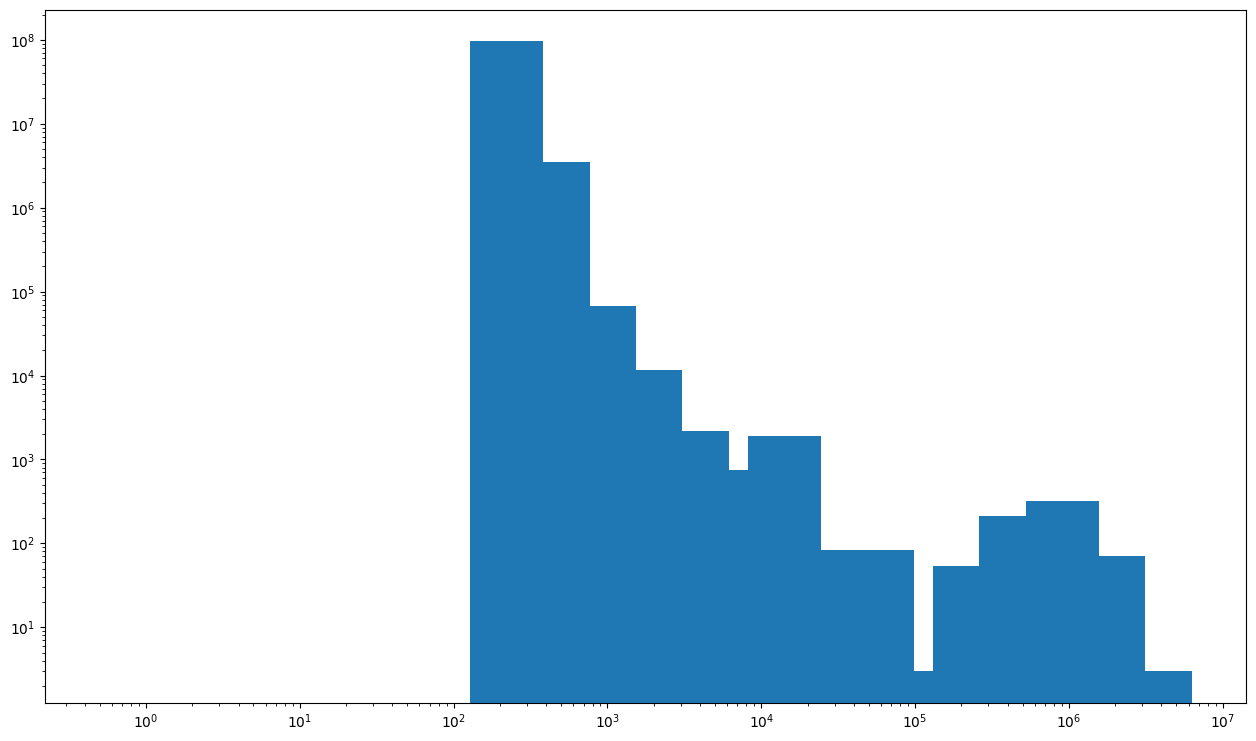

In [145]:

val_counts =[(x.value_iterated_from,  x.count_added_in_this_iter_step) for x in hist1.get_log_iterator(1, 2)]
xs = [x[0]for x in val_counts]
ys = [x[1] for x in val_counts]
fig1,ax1 = plt.subplots()
fig1.set_size_inches(15.5, 9)
ax1.set_yscale('log')
ax1.set_xscale("log")
ax1.bar(xs[:-1],ys[:-1],width=np.diff(xs))    
plt.show()


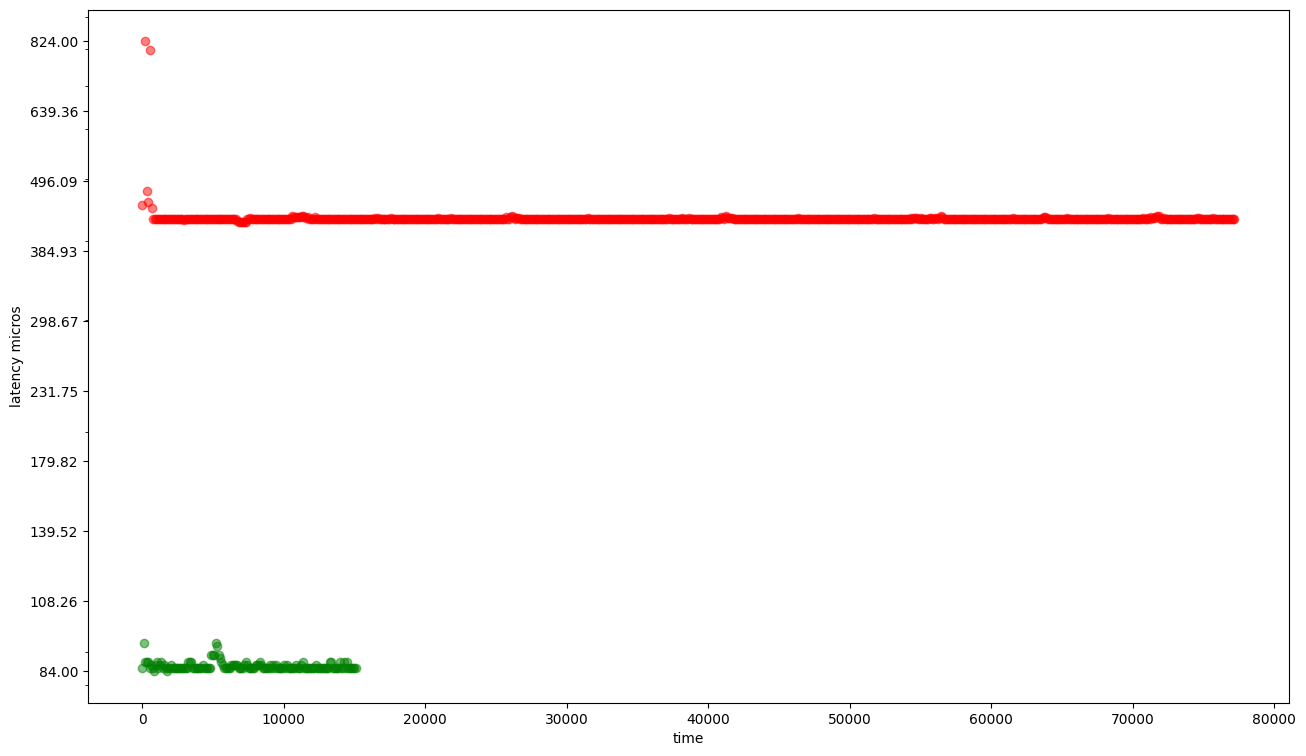

In [85]:
plot_percentile_diff(time_series0, time_series1, label='p50')

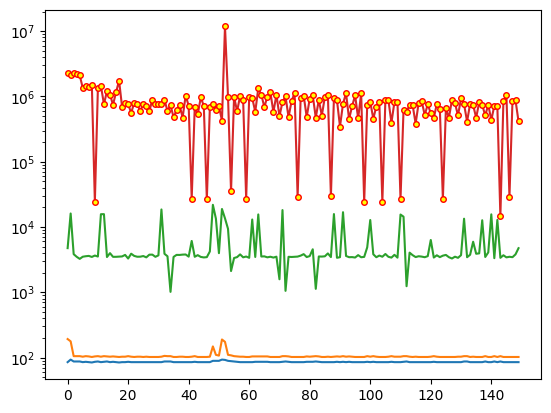

In [51]:
time_series = percentile_df(HDR_LOG_NAME)
plot_percentile(time_series)

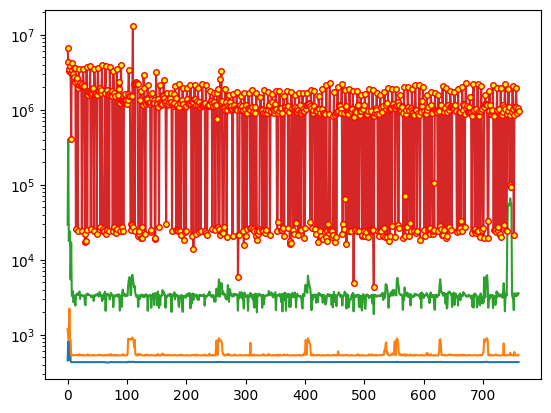

In [54]:
time_series = percentile_df(HDR_LOG_2)
plot_percentile(time_series)